In [1]:
import os

import dask.diagnostics
import faceted
import numpy as np
import pandas as pd
import wandb
import xarray as xr

import plotting

In [2]:
def wandb_id_from_name(name):
    api = wandb.Api()
    runs = api.runs("ai2cm/ace-shield", filters={"display_name": {"$regex": name}})
    completed = [run for run in runs if run.state == "finished"]
    return completed[-1]

SHIELD_RUNS = {
    f"SHiELD-4xCO2-ic_{ic}": wandb_id_from_name(f"shield-data-only-evaluator-abrupt4xCO2-ic-{ic:04d}") for ic in range(1, 37)
}

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/spencerc/.netrc.


In [3]:
def load_metrics_from_wandb(run, keys, offset_time=1):
    history = pd.DataFrame(run.scan_history(keys=keys))
    ds = xr.Dataset.from_dataframe(history)
    ds = ds.rename({"index": "time"})
    ds["time"] = (6 * (ds.time + offset_time)).astype("timedelta64[h]").astype("timedelta64[us]")
    ds = ds.assign_coords(time=ds.time)
    return ds.rename({s: s.rsplit('/', 1)[-1] for s in ds.data_vars})

In [4]:
VARIABLE_NAMES = ["implied_tendency_of_total_energy_ace2_path_due_to_advection"]
METRIC_NAMES = [f"inference/mean/weighted_mean_gen/{var}" for var in VARIABLE_NAMES]

In [5]:
# Initialize an empty dictionary to store the data
ds_shield = []

# Loop through each model and case to extract the metric data
for run in SHIELD_RUNS.values():
    ds = load_metrics_from_wandb(run, METRIC_NAMES)
    ds_shield.append(ds)
da_shield = xr.concat(ds_shield, dim="sample").implied_tendency_of_total_energy_ace2_path_due_to_advection

In [6]:
ROOT_1xCO2 = "gs://vcm-ml-experiments/spencerc/2026-09-09-1xCO2-ensemble-inference"
ROOT_4xCO2 = "gs://vcm-ml-experiments/spencerc/2026-09-09-abrupt-4xCO2-ensemble-inference"
MODELS = [
    "published-baseline-rs3",
    "no-random-co2-rs0", 
    "no-random-co2-rs1", 
    "no-random-co2-energy-conserving-rs0", 
    "no-random-co2-energy-conserving-rs1", 
    "full-rs0",
    "full-rs1", 
    "full-energy-conserving-rs0", 
    "full-energy-conserving-rs1",
]

In [7]:
def load_datasets(root, models):
    datasets = {}
    for model in models:
        path = os.path.join(root, model, "6h_predictions.zarr")
        datasets[model] = xr.open_zarr(path, chunks={"time": 40})
    return xr.concat(datasets.values(), dim=pd.Index(datasets.keys(), name="model"))

In [8]:
# ds_1xCO2 = load_datasets(ROOT_1xCO2, MODELS)
ds_4xCO2 = load_datasets(ROOT_4xCO2, MODELS)

/tmp/ipykernel_95878/424481895.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  datasets[model] = xr.open_zarr(path, chunks={"time": 40})
/tmp/ipykernel_95878/424481895.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  datasets[model] = xr.open_zarr(path, chunks={"time": 40})
/tmp/ipykernel_95878/424481895.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  datasets[model] = xr.open_zarr(path, chunks={"time": 40})
/tmp/ipykernel_95878/424481895.py:5: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 40. This could degrade p

In [9]:
weights = np.cos(np.deg2rad(ds_4xCO2.lat))

In [10]:
with dask.diagnostics.ProgressBar():
    global_mean = ds_4xCO2.implied_tendency_of_total_energy_ace2_path_due_to_advection.weighted(weights).mean(["lat", "lon"]).compute()

[########################################] | 100% Completed | 10m 50s


In [11]:
COLORS = {
    "SHiELD": "k",
    "published-baseline-rs3": "C3",
    "no-random-co2-rs0": "C1",
    "no-random-co2-energy-conserving-rs0": "C2",
    "full-rs1": "C5",
    "full-energy-conserving-rs0": "C4"
}

In [12]:
combined = xr.concat([global_mean.assign_coords(time=global_mean.time.astype("timedelta64[us]")), xr.concat([da_shield], dim=pd.Index(["SHiELD"], name="model"))], dim="model")
combined = combined.assign_coords(time=combined.time / np.timedelta64(1, "D"))

/tmp/ipykernel_95878/2280929303.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  combined = xr.concat([global_mean.assign_coords(time=global_mean.time.astype("timedelta64[us]")), xr.concat([da_shield], dim=pd.Index(["SHiELD"], name="model"))], dim="model")


In [13]:
combined.isel(time=slice(4, None)).mean("time").mean("sample")

<xarray.DataArray 'implied_tendency_of_total_energy_ace2_path_due_to_advection' (
                                                                                 model: 10)> Size: 80B
array([ 9.57568713, 12.7511903 , 11.33334914,  1.13000323,  1.12995492,
        2.4648198 ,  2.1882915 ,  1.12995785,  1.12991834,  1.09697102])
Coordinates:
  * model    (model) StringDType(na_object=nan) 160B 'published-baseline-rs3'...
Attributes:
    units:      W/m**2
    long_name:  Implied advective tendency of total energy path assuming clos...

In [14]:
LABELS = {
    "SHiELD": "SHiELD",
    "published-baseline-rs3": "ACE2-SOM",
    "no-random-co2-rs0": "ACE2S-SHiELD+$_{\\text{no-RC-no-EC}}$",
    "no-random-co2-energy-conserving-rs0": "ACE2S-SHiELD+$_{\\text{no-RC}}$",
    "full-rs1": "ACE2S-SHiELD+$_{\\text{no-EC}}$",
    "full-energy-conserving-rs0": "ACE2S-SHiELD+",
}
ZORDER = {
    "SHiELD": 3,
    "published-baseline-rs3": 0,
    "no-random-co2-rs0": 1,
    "no-random-co2-energy-conserving-rs0": 4,
    "full-rs1": 2,
    "full-energy-conserving-rs0": 5,
}
ALTERNATE_SEEDS = {
    "no-random-co2-rs0": "no-random-co2-rs1",
    "no-random-co2-energy-conserving-rs0": "no-random-co2-energy-conserving-rs1",
    "full-rs1": "full-rs0",
    "full-energy-conserving-rs0": "full-energy-conserving-rs1",
}

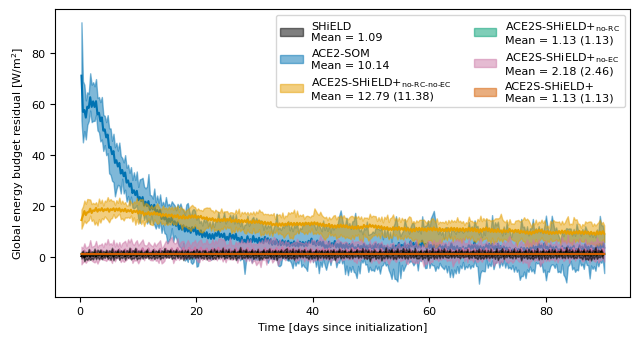

In [17]:
plotting.configure_style()

fig, (ax, ) = faceted.faceted(1, 1, width=6.5, aspect=0.5, left_pad=0.5, bottom_pad=0.5)

for model, color in COLORS.items():
    m = combined.sel(model=model).mean(["time", "sample"]).item()
    if model in ALTERNATE_SEEDS:
        alternate_model = ALTERNATE_SEEDS[model]
        m_alternate = combined.sel(model=alternate_model).mean(["time", "sample"]).item()
        label = f"{LABELS[model]}\nMean = {m:0.2f} ({m_alternate:0.2f})"
    else:
        label = f"{LABELS[model]}\nMean = {m:0.2f}"
    zorder = ZORDER[model]
    ax.fill_between(combined.time, combined.min("sample").sel(model=model), combined.max("sample").sel(model=model), color=color, alpha=0.5, label=label, zorder=zorder)
    combined.mean("sample").sel(model=model).plot(ax=ax, color=color, zorder=zorder)

ax.set_xlabel("Time [days since initialization]")
ax.set_ylabel("Global energy budget residual [W/m$^2$]")
ax.set_title("")
ax.legend(ncol=2)

fig.patch.set_alpha(0.0)
fig.savefig("figure-energy-budget-residual.png", dpi=300)
fig.savefig("figure-energy-budget-residual.pdf")